# Hidden reserves on the balance sheet. Buried treasure, or just buried? 🛡️
### A conservatism score with real accounting theory behind it — and a stock return of exactly nothing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Conservative%3F: Suggestive](https://img.shields.io/badge/Conservative%3F-Suggestive-8b949e?style=flat-square)

Here's a signal with a Nobel-adjacent pedigree. *Conservative* accounting books bad news the instant it's plausible but makes good news wait until it's certain — the prudent, lower-of-cost-or-market instinct. A side effect is that conservative firms quietly stuff the balance sheet with **hidden reserves**: allowances for bad debts, inventory write-down reserves, valuation allowances. Book value understates economic value, and those reserves later melt back into earnings. The pitch writes itself: find the most conservative firms — the ones sitting on the biggest reserve cushion — and you've found un-booked value the market hasn't paid for yet. Buy them.

It's a lovely story. The accounting part is even mildly true. The *buy them* part is where it falls apart.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the Basu regression and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 37 US non-financial names that tag reserve/allowance accounts on EDGAR, 2008→2026; a genuinely **coarse proxy** (XBRL exposes only a slice of the reserves the theory wants) on a **thin, uneven panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from conservatism import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 37, 'n_events': 1669, 'end_lo': '2008-09-27', 'end_hi': '2026-05-31', 'fp_prices': '5506b659db08', 'cscore_med': 0.34, 'cscore_mean': 0.98, 'n_months': 202, 'avg_n': 28.5, 'ls_span_lo': '2009-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 4.0, 'ls_ann': 0.49, 'ls_t_iid': 0.21, 'ls_t_nw': 0.22, 'ls_sharpe': 0.05, 'ls_hit': 49, 'ls_long_bps': 152.4, 'ls_short_bps': 148.4, 'ls_turn': 0.21, 'ls_cum': 1.005, 'ls120_mean_bps': -9.4, 'ls120_t_nw': -0.43, 'noa_n': 194, 'noa_mean_bps': 0.6, 'noa_t_nw': 0.02, 'xsec_early': 20, 'xsec_late': 31, 'noa_cov': 42, 'drift': {21: (1667, 1.4, 1.47, -0.07, -0.17, 49, 0.565), 63: (1646, 3.57, 4.26, -0.68, -0.91, 49, 0.8345), 126: (1615, 6.55, 7.91, -1.36, -1.31, 48, 0.9211)}, 'mono63': (4.26, 2.57, 3.57), 'mono126': (7.91, 5.62, 6.55), 'era_early_n': 76, 'era_early_bps': 17.8, 'era_early_t': 0.55, 'era_late_n': 126, 'era_late_bps': -4.3, 'era_late_t': -0.2, 'basu_n': 1607, 'basu_b_good': 0.006, 'basu_b_asym': 0.025, 'basu_t': 1.67, 'basu_r2': 0.005, 'net': {(10, 50): (-4.3, -0.51, -0.24, -0.05), (20, 100): (-12.5, -1.51, -0.7, -0.16)}, 'syn_null_mean': 0.47, 'syn_null_sd': 0.76, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 1057.5, 'syn_planted_t': 26.57}


real cache present: True | events: 1669 | names: 37


## The answer first

| Question | Answer |
|---|---|
| Is the accounting actually **conservative**? | **Mildly.** Earnings react a little more to bad news than good (Basu asymmetry +0.025), but faintly (*t* = +1.67, explaining ~0.5% of the variation). A real property, weakly present. |
| Does a high conservatism score predict future **returns**? | **No.** A long-short that buys the most-conservative names and shorts the least earns **+0.5%/yr** gross — a flat line, \$1 → \$1.005 over 17 years (robust *t* = **+0.22**, the bar is 2). If anything the most-conservative names *lag*. |
| Why the gap? | The reserve balances are **public** and the score is **coarse**. Anyone can read the allowance line; the market prices whatever it means on filing day. A faint accounting property is not a stock signal. |
| Can you trade it? | **No.** There's no gross edge to charge costs against — net of friction the book loses money. |

> A real (if weak) accounting phenomenon. No alpha in the stock. That distinction is the whole study.

## 1 · The claim

> *"Conservative accounting hides value. Prudent firms build reserves that understate their true worth, and those reserves unwind into earnings later — so buy the firms carrying the biggest reserve cushion."*

It's the strong form of a respectable academic idea. **Basu (1997)** defined conservatism as earnings reacting faster to bad news than good; **Penman & Zhang (2002)** built a *C-score* — estimated reserves over net operating assets — and argued it signals earnings quality and future returns. The question is whether that accounting property is also a *trading* signal.

## 2 · So what?

If a plain balance-sheet ratio — reserves divided by assets — predicted stock returns, it would be one of the easiest anomalies going: no estimates feed, no alt-data, just a couple of lines from every 10-Q. That's exactly why it deserves suspicion. Everyone with a brokerage account can pull the allowance for doubtful accounts. If markets price public information at all, this is the kind they should price fastest.

## 3 · How would we even know?

- **The score.** For each of 37 non-financial names, add up the tagged reserve accounts (bad-debt allowance + inventory reserve + deferred-tax valuation allowance) and divide by assets — known only on the **filing date** of the 10-Q/10-K (no peeking).
- **The conservatism test.** Does the panel actually book bad news faster than good (the Basu asymmetry)? If not, the score can't even be a proxy for what it claims.
- **The return test.** Each month, rank the names on the score, buy the most conservative third, short the least, hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**The money question first: do the most-conservative stocks out-return the least?** Rank on the score each month, buy the top third, short the bottom third, and track the growth of \$1.

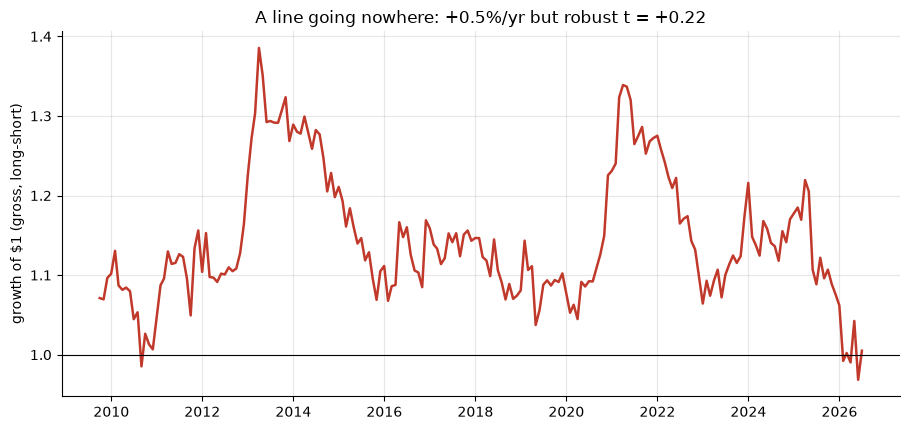

long-short: +0.5%/yr gross, Newey-West t = +0.22 (the bar is 2)


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='cscore', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=RED, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A line going nowhere: +{ann:.1f}%/yr but robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: +{ann:.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

That is about as flat as a strategy line gets: **+0.5%/yr** gross, \$1 growing to \$1.005 over 202 months, robust *t* = **+0.22** against a bar of 2. Not a decaying edge, not a costed-away edge — just **no edge**.

**The tell:** if the score really sorted returns, the middle third would land between the top and bottom, and the top (most conservative) would win. Instead the thirds are jumbled — and if anything the *most*-conservative names trail.

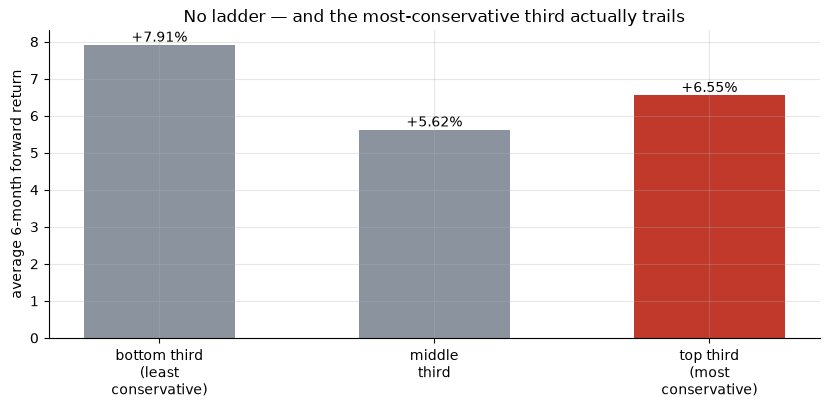

6-month forward return by conservatism third (low->high): ['+7.91%', '+5.62%', '+6.55%']


In [3]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=126)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono126'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom third\n(least\nconservative)','middle\nthird','top third\n(most\nconservative)'], mono,
       color=[GREY, GREY, RED], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 6-month forward return')
ax.set_title('No ladder — and the most-conservative third actually trails')
plt.tight_layout(); plt.show()
print('6-month forward return by conservatism third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase — and the wrong slope. Over the next two quarters the *least*-conservative third returns **+7.9%** and the *most*-conservative third only **+6.5%**. A random relabelling of the names beats the real long-short ~9 times in 10. Whatever hidden reserves are doing for the business, they are not buying these stocks a higher return.

**So is the accounting even conservative in the first place?** We check the Basu signature directly: do earnings react more to bad news (negative stock returns) than to good?

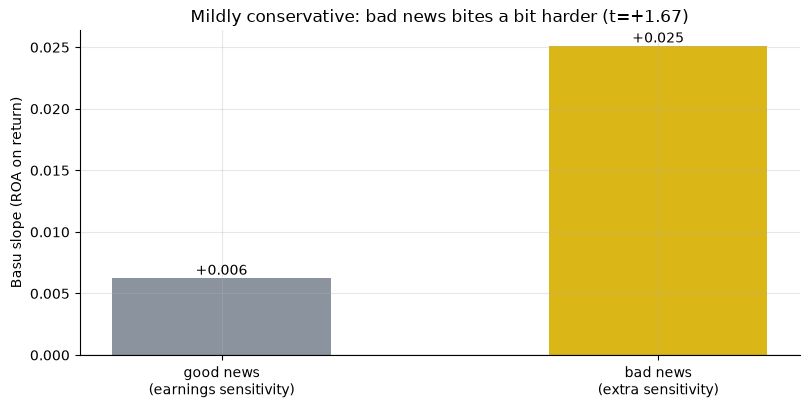

Basu: good-news slope +0.006, extra bad-news slope +0.025 (t=+1.67)


In [4]:
if HAVE_REAL:
    q = st.basu_asymmetry(EV)
    b_good, b_asym, t_asym = q['b_good'], q['b_asym'], q['t_asym']
else:
    b_good, b_asym, t_asym = R['basu_b_good'], R['basu_b_asym'], R['basu_t']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(['good news\n(earnings sensitivity)','bad news\n(extra sensitivity)'],
       [b_good, b_asym], color=[GREY, AMBER], width=.5)
for i,v in enumerate([b_good, b_asym]): ax.annotate(f'{v:+.3f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('Basu slope (ROA on return)')
ax.set_title(f'Mildly conservative: bad news bites a bit harder (t={t_asym:+.2f})')
plt.tight_layout(); plt.show()
print(f'Basu: good-news slope {b_good:+.3f}, extra bad-news slope {b_asym:+.3f} (t={t_asym:+.2f})')

There *is* a bad-news asymmetry — the extra sensitivity to bad news is **+0.025** — so the panel is genuinely, if faintly, conservative (*t* = +1.67; strong-but-not-overwhelming). The accounting theory isn't fantasy. It just doesn't convert into a stock edge: the conservatism is real, weak, public, and already priced.

## 5 · The verdict

- **Signal (returns) — None.** The long-short is a flat +0.5%/yr with robust *t* = +0.22, non-monotone thirds, a placebo the real strategy *loses* to, and (if anything) the most-conservative names trailing. No premium here.
- **Tradability — Mirage.** No gross edge to monetise; net of costs the book loses money.
- **Is it conservative? — Suggestive.** A faint but real Basu bad-news asymmetry (+0.025, *t* = +1.67). The property exists; the coarse reserve proxy captures it poorly; and it buys no return.

> The honest one-liner: *conservative firms really do hide a little value — and the market has already counted it.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* of a public reserve ratio, but maybe in the *change* — reserve *releases* that flatter earnings (the Penman-Zhang change-in-conservatism story), or a sharper C-score built from the reserves XBRL doesn't expose (LIFO, capitalised R&D and advertising). That's the residual this coarse study didn't chase.
- **The coverage caveat is real.** Reserve tags are irregular — most names disclose only the bad-debt allowance, and only in some years — so our score is a *floor* on true reserves and the cross-section is thin (≈20 names early, ≈31 late; only 42% carry the cleaner NOA denominator).
- **Sibling studies:** [229-beneish-m-score](../../229-beneish-m-score/) (detects the *opposite* — income-inflating manipulation), [232-mohanram-g-score](../../232-mohanram-g-score/) (a growth-firm fundamental composite), [855-accrual-quality](../../855-accrual-quality/) (how well accruals map to cash), and [52-smoke-screen](../../52-smoke-screen/) (the method-demo cousin of a good-story-no-reward null). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in reserve *changes*, not levels? Build the release signal, show a certifiable net spread on the size you'd actually run — then we'll talk.*